# Doprinos 4 — Analiza uticaja Beam Search parametra na tačnost i brzinu Faster-Whisper transkripcije

## Cilj eksperimenta

Cilj eksperimenta je analiza uticaja `beam_size` parametra na tačnost i brzinu Faster-Whisper transkripcije prirodnog srpskog govora.

Eksperiment je sproveden na **15 reprezentativnih audio zapisa** različitih dužina i različitih govornika. U svim testovima koristi se isti Faster-Whisper `base` model, CPU izvršavanje i INT8 kvantizacija, dok se menja samo vrednost `beam_size` parametra: **1, 3, 5 i 10**.

Za svaku konfiguraciju mere se WER, vreme transkripcije i Real-Time Factor (RTF), sa ciljem da se utvrdi da li šira beam pretraga donosi poboljšanje tačnosti i koliki dodatni vremenski trošak zahteva.


In [1]:
from pathlib import Path
import re
import time
import wave
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from faster_whisper import WhisperModel
from jiwer import wer


# ============================================================
# PUTANJE
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

AUDIO_DIR = PROJECT_ROOT / "audio" / "40Sentences00-08Notebooks"

REZULTATI_DIR = PROJECT_ROOT / "rezultati" / "04_uticaj_beam_searcha"
REZULTATI_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("AUDIO_DIR:", AUDIO_DIR)
print("REZULTATI_DIR:", REZULTATI_DIR)

PROJECT_ROOT: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR
AUDIO_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks
REZULTATI_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\04_uticaj_beam_searcha


In [2]:
# ============================================================
# TEST SKUP — 15 PRIRODNIH SRPSKIH SNIMAKA
# ============================================================

test_set = [
    {
        "broj": 1,
        "audio": AUDIO_DIR / "1govornik1.wav",
        "govornik": "govornik1",
        "grupa": "kratki",
        "ref": "Veštačka inteligencija omogućava računarima da rešavaju složene probleme i analiziraju velike količine podataka."
    },
    {
        "broj": 4,
        "audio": AUDIO_DIR / "4govornik1.wav",
        "govornik": "govornik1",
        "grupa": "kratki",
        "ref": "Novi računari imaju brže procesore, više memorije i znatno bolje performanse nego prethodne generacije."
    },
    {
        "broj": 8,
        "audio": AUDIO_DIR / "8govornik3.wav",
        "govornik": "govornik3",
        "grupa": "kratki",
        "ref": "Temperatura je tokom noći naglo pala, ali se očekuje da će sutra vreme ponovo biti toplije."
    },
    {
        "broj": 11,
        "audio": AUDIO_DIR / "11govornik1.wav",
        "govornik": "govornik1",
        "grupa": "srednji",
        "ref": "Savremeni sistemi za automatsko prepoznavanje govora koriste duboke neuronske mreže kako bi analizirali zvučni signal i pretvorili ga u tekst. Njihova tačnost zavisi od modela, kvaliteta snimka, jezika i karakteristika govornika."
    },
    {
        "broj": 14,
        "audio": AUDIO_DIR / "14govornik1.wav",
        "govornik": "govornik1",
        "grupa": "srednji",
        "ref": "Kada razgovaramo u tihoj prostoriji, sistem uglavnom može veoma jasno da prepozna izgovorene reči. Međutim, saobraćaj, muzika, razgovor drugih ljudi i različiti izvori šuma mogu značajno da otežaju transkripciju."
    },
    {
        "broj": 18,
        "audio": AUDIO_DIR / "18govornik2.wav",
        "govornik": "govornik2",
        "grupa": "srednji",
        "ref": "Brzina automatskog prepoznavanja govora posebno je važna kod aplikacija koje rade u realnom vremenu. Korisnik očekuje da sistem reaguje brzo i da se transkript pojavljuje bez primetnog kašnjenja."
    },
    {
        "broj": 21,
        "audio": AUDIO_DIR / "21govornik3.wav",
        "govornik": "govornik3",
        "grupa": "srednji",
        "ref": "Kvantizacija omogućava da se neuronski model izvršava korišćenjem manje preciznih numeričkih formata. Na taj način moguće je smanjiti potrošnju memorije i ubrzati izvršavanje uz prihvatljivu promenu tačnosti."
    },
    {
        "broj": 24,
        "audio": AUDIO_DIR / "24govornik3.wav",
        "govornik": "govornik3",
        "grupa": "srednji",
        "ref": "Kada se zvučnom signalu doda šum, neke reči postaju teže razumljive. Što je nivo šuma veći u odnosu na govor, sistemu je teže da napravi tačnu transkripciju celog snimka."
    },
    {
        "broj": 27,
        "audio": AUDIO_DIR / "27govornik1.wav",
        "govornik": "govornik1",
        "grupa": "dugi",
        "ref": "Jednog jutra krenuo sam automobilom prema gradu nešto ranije nego obično. Saobraćaj je u početku bio veoma slab, ali se približavanjem centru broj vozila postepeno povećavao. Dok sam čekao na semaforu, na radiju su govorili o vremenskoj prognozi za narednih nekoliko dana. Najavljeno je sunčano vreme, ali i mogućnost kratkotrajne kiše tokom vikenda. Kada sam stigao, parkirao sam automobil i nastavio pešice."
    },
    {
        "broj": 30,
        "audio": AUDIO_DIR / "30govornik2.wav",
        "govornik": "govornik2",
        "grupa": "dugi",
        "ref": "Kada razvijamo sistem koji treba da radi u realnom vremenu, nije dovoljno posmatrati samo njegovu tačnost. Potrebno je analizirati koliko vremena modelu treba da obradi određenu količinu zvuka. Ako obrada pet sekundi govora traje kraće od pet sekundi, sistem potencijalno može da prati govor bez stalnog povećavanja kašnjenja. Zbog toga su latencija i faktor realnog vremena veoma korisne metrike prilikom evaluacije ovakvih sistema."
    },
    {
        "broj": 32,
        "audio": AUDIO_DIR / "32govornik3.wav",
        "govornik": "govornik3",
        "grupa": "dugi",
        "ref": "Ljudski govor nije potpuno konstantan signal. Neko govori brzo, neko sporije, a pojedini govornici prave veoma duge pauze između rečenica. Razlikuju se i visina glasa, naglasak, način izgovora i jačina govora. Sistem koji postiže odlične rezultate kod jednog govornika zato ne mora nužno da postigne iste rezultate kod druge osobe. Korišćenje više govornika omogućava realniju procenu sposobnosti modela da generalizuje."
    },
    {
        "broj": 34,
        "audio": AUDIO_DIR / "34govornik3.wav",
        "govornik": "govornik3",
        "grupa": "dugi",
        "ref": "Beam search predstavlja jedan od načina pronalaženja verovatne sekvence reči tokom dekodiranja rezultata modela. Veća vrednost parametra omogućava razmatranje većeg broja mogućih kandidata, ali istovremeno može da poveća vreme potrebno za obradu. Zbog toga je korisno eksperimentalno proveriti da li povećanje beam size parametra zaista donosi značajno poboljšanje tačnosti i koliko dodatnih računarskih resursa zahteva."
    },
    {
        "broj": 36,
        "audio": AUDIO_DIR / "36govornik1.wav",
        "govornik": "govornik1",
        "grupa": "veoma_dugi",
        "ref": "Savremeni sistemi za automatsko prepoznavanje govora imaju veliki broj praktičnih primena. Mogu se koristiti za automatsko pravljenje transkripata sastanaka, generisanje titlova, glasovne asistente, pretragu multimedijalnog sadržaja i poboljšanje pristupačnosti digitalnih sistema. Ipak, kvalitet njihovog rada zavisi od velikog broja faktora. Govornici imaju različite glasove, akcente i brzine govora, dok snimci mogu nastati korišćenjem različitih mikrofona i u različitim prostorijama. Dodatni problem predstavlja pozadinski šum. Sistem koji veoma dobro radi u tihoj prostoriji ne mora da postigne isti rezultat na ulici ili u automobilu. Zbog toga evaluacija sistema ne bi trebalo da bude zasnovana na samo jednom zvučnom zapisu. Potrebno je koristiti više govornika, različite dužine snimaka i različite uslove. Pored tačnosti transkripcije, važno je analizirati vreme izvršavanja, potrošnju memorije i sposobnost sistema da obrađuje zvuk dovoljno brzo za praktičnu primenu."
    },
    {
        "broj": 38,
        "audio": AUDIO_DIR / "38govornik2.wav",
        "govornik": "govornik2",
        "grupa": "veoma_dugi",
        "ref": "Prošle nedelje imao sam prilično ispunjen dan. Ujutru sam ustao ranije jer sam morao da završim nekoliko obaveza pre odlaska u grad. Posle doručka proverio sam poruke, pripremio stvari koje su mi bile potrebne i krenuo automobilom. Na putu je bilo više saobraćaja nego što sam očekivao, pa mi je trebalo skoro pola sata da stignem do centra. Prvo sam otišao do prodavnice, zatim do banke, a nakon toga sam se našao sa prijateljem kojeg nisam video nekoliko meseci. Razgovarali smo o poslu, putovanjima i planovima za narednu godinu. Posle ručka vreme se iznenada promenilo i počela je jaka kiša. Sačekali smo nekoliko minuta da se vreme malo smiri, a onda smo krenuli kući. Kada sam se vratio, nastavio sam da radim na računaru. Uveče sam završio preostale obaveze i odlučio da ostatak dana provedem odmarajući se."
    },
    {
        "broj": 40,
        "audio": AUDIO_DIR / "40govornik3.wav",
        "govornik": "govornik3",
        "grupa": "veoma_dugi",
        "ref": "Cilj eksperimentalne analize sistema za automatsko prepoznavanje govora jeste da se utvrdi kako različiti faktori utiču na njegov rad. Možemo menjati veličinu modela, nivo pozadinskog šuma, jezik govornika, parametre dekodiranja, način kvantizacije ili korišćenje algoritma za detekciju govora. Svaki eksperiment treba organizovati tako da možemo jasno da utvrdimo posledice određene promene. Rezultati se zatim mogu posmatrati kroz više metrika. Word Error Rate pokazuje koliko se prepoznati tekst razlikuje od tačnog referentnog transkripta. Latencija pokazuje koliko vremena je potrebno za obradu, dok Real-Time Factor povezuje vreme obrade sa trajanjem samog zvučnog zapisa. Potrošnja memorije je posebno značajna kada model treba da radi na uređajima sa ograničenim resursima. Kombinovanjem ovih rezultata možemo da pronađemo konfiguraciju koja ne mora biti najbolja prema svakoj pojedinačnoj metrici, ali predstavlja dobar kompromis između tačnosti, brzine i potrebnih računarskih resursa."
    }
]


for item in test_set:
    if not item["audio"].exists():
        raise FileNotFoundError(
            f"Audio fajl nije pronađen: {item['audio']}"
        )

print(f"Sva {len(test_set)} audio fajla su pronađena.")

Sva 15 audio fajla su pronađena.


In [3]:
# ============================================================
# POMOĆNE FUNKCIJE
# ============================================================

def normalizuj_tekst(tekst):
    tekst = tekst.lower().strip()
    tekst = re.sub(
        r"[^\w\sčćžšđ]",
        " ",
        tekst,
        flags=re.UNICODE
    )
    tekst = re.sub(
        r"\s+",
        " ",
        tekst
    ).strip()
    return tekst


def izracunaj_wer(referenca, hipoteza):
    return wer(
        normalizuj_tekst(referenca),
        normalizuj_tekst(hipoteza)
    )


def trajanje_wav(putanja):
    with wave.open(str(putanja), "rb") as f:
        return f.getnframes() / float(f.getframerate())

In [4]:
# ============================================================
# MODEL
# ============================================================

model = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

print("Faster-Whisper base INT8 je učitan.")

Faster-Whisper base INT8 je učitan.


## Metodologija

Beam search predstavlja strategiju dekodiranja kod koje se tokom generisanja transkripta istovremeno razmatra više mogućih kandidata. Veća vrednost `beam_size` proširuje prostor pretrage, ali istovremeno može povećati vreme potrebno za dekodiranje.

U ovom eksperimentu testirane su vrednosti `beam_size = 1, 3, 5 i 10`. Svaka konfiguracija primenjuje se na potpuno isti skup od 15 audio zapisa, uz nepromenjen model i ostale uslove izvršavanja.

Na ovaj način razlike u WER-u i vremenu izvršavanja mogu se direktnije povezati sa promenom `beam_size` parametra.


In [5]:
# ============================================================
# BEAM SEARCH EKSPERIMENT
# ============================================================

beam_opcije = [1, 3, 5, 10]

rezultati_po_fajlu = []
rezime_beam = []


for beam in beam_opcije:

    print("\n" + "=" * 90)
    print(f"POKREĆE SE BEAM_SIZE = {beam}")
    print("=" * 90)

    vremena = []
    rtf_vrednosti = []
    wer_vrednosti = []


    for indeks, item in enumerate(test_set, start=1):

        trajanje = trajanje_wav(item["audio"])

        start = time.perf_counter()

        segments, info = model.transcribe(
            str(item["audio"]),
            language="sr",
            beam_size=beam
        )

        transkript = " ".join(
            segment.text.strip()
            for segment in segments
        ).strip()

        vreme = time.perf_counter() - start

        greska = izracunaj_wer(
            item["ref"],
            transkript
        )

        rtf = vreme / trajanje

        vremena.append(vreme)
        rtf_vrednosti.append(rtf)
        wer_vrednosti.append(greska)


        rezultati_po_fajlu.append({
            "Beam Size": beam,
            "Broj": item["broj"],
            "Audio": item["audio"].name,
            "Govornik": item["govornik"],
            "Grupa_duzine": item["grupa"],
            "Trajanje [s]": round(trajanje, 3),
            "Vreme [s]": round(vreme, 3),
            "RTF": round(rtf, 4),
            "WER": round(greska, 4),
            "WER [%]": round(greska * 100, 2),
            "Referenca": item["ref"],
            "Transkript": transkript
        })


        print(
            f"[{indeks:02d}/{len(test_set)}] "
            f"{item['audio'].name:<20} | "
            f"{vreme:6.2f} s | "
            f"RTF {rtf:6.3f} | "
            f"WER {greska * 100:6.2f}%"
        )


    rezime_beam.append({
        "Beam Size": beam,
        "Broj snimaka": len(test_set),
        "Prosečno vreme [s]": round(np.mean(vremena), 3),
        "Ukupno vreme [s]": round(np.sum(vremena), 3),
        "Prosečan RTF": round(np.mean(rtf_vrednosti), 4),
        "Prosečan WER [%]": round(np.mean(wer_vrednosti) * 100, 2),
        "Medijana WER [%]": round(np.median(wer_vrednosti) * 100, 2)
    })


df_detaljno = pd.DataFrame(rezultati_po_fajlu)
tabela_beam = pd.DataFrame(rezime_beam)


POKREĆE SE BEAM_SIZE = 1
[01/15] 1govornik1.wav       |   1.27 s | RTF  0.167 | WER  38.46%
[02/15] 4govornik1.wav       |   1.11 s | RTF  0.152 | WER  42.86%
[03/15] 8govornik3.wav       |   1.10 s | RTF  0.211 | WER  56.25%
[04/15] 11govornik1.wav      |   1.53 s | RTF  0.093 | WER  29.03%
[05/15] 14govornik1.wav      |   1.62 s | RTF  0.104 | WER  65.52%
[06/15] 18govornik2.wav      |   1.41 s | RTF  0.078 | WER  32.14%
[07/15] 21govornik3.wav      |   1.63 s | RTF  0.112 | WER  51.85%
[08/15] 24govornik3.wav      |   1.57 s | RTF  0.135 | WER  55.17%
[09/15] 27govornik1.wav      |   2.25 s | RTF  0.082 | WER  58.06%
[10/15] 30govornik2.wav      |   3.15 s | RTF  0.084 | WER  28.57%
[11/15] 32govornik3.wav      |   2.34 s | RTF  0.084 | WER  65.00%
[12/15] 34govornik3.wav      |   3.29 s | RTF  0.099 | WER  74.55%
[13/15] 36govornik1.wav      |   5.39 s | RTF  0.078 | WER  54.62%
[14/15] 38govornik2.wav      |   4.62 s | RTF  0.072 | WER  35.77%
[15/15] 40govornik3.wav      |   5.2

In [6]:
# ============================================================
# GLAVNA TABELA
# ============================================================

print("=" * 90)
print("UTICAJ BEAM SEARCH PARAMETRA — ZAVRŠNI REZULTATI")
print("=" * 90)

display(tabela_beam)

UTICAJ BEAM SEARCH PARAMETRA — ZAVRŠNI REZULTATI


,Beam Size,Broj snimaka,Prosečno vreme [s],Ukupno vreme [s],Prosečan RTF,Prosečan WER [%],Medijana WER [%]
0,1,15,2.499,37.482,0.1076,49.09,51.85
1,3,15,3.276,49.145,0.1218,44.48,48.15
2,5,15,4.045,60.674,0.1425,43.17,48.15
3,10,15,6.439,96.586,0.1988,43.76,48.15


## Analiza ukupnih rezultata

Povećanje `beam_size` sa 1 na 3 i 5 dovelo je do smanjenja prosečnog WER-a, ali uz povećanje vremena obrade.

Za `beam_size = 1` prosečan WER iznosi **49,09%**, prosečno vreme transkripcije **2,499 s**, a prosečan RTF **0,1076**. Povećanjem na `beam_size = 3`, prosečan WER se smanjuje na **44,48%**, dok vreme raste na **3,276 s**.

Najniži prosečan WER ostvaren je sa `beam_size = 5` i iznosi **43,17%**, uz prosečno vreme od **4,045 s** i RTF od **0,1425**.

Dalje povećanje na `beam_size = 10` nije dodatno smanjilo prosečan WER, koji iznosi **43,76%**, dok je prosečno vreme poraslo na **6,439 s**, a RTF na **0,1988**.

Rezultati zato pokazuju efekat opadajućeg prinosa: povećanje beam vrednosti u početku poboljšava prosečnu tačnost, ali nakon `beam_size = 5` dodatno proširenje pretrage u ovom testu ne donosi poboljšanje prosečnog WER-a koje bi pratilo znatno veći vremenski trošak.


In [7]:
# ============================================================
# DETALJNI REZULTATI
# ============================================================

display(
    df_detaljno[
        [
            "Beam Size",
            "Broj",
            "Audio",
            "Govornik",
            "Grupa_duzine",
            "Trajanje [s]",
            "Vreme [s]",
            "RTF",
            "WER [%]"
        ]
    ]
)

,Beam Size,Broj,Audio,Govornik,Grupa_duzine,Trajanje [s],Vreme [s],RTF,WER [%]
0,1,1,1govornik1.wav,govornik1,kratki,7.605,1.271,0.1672,38.46
1,1,4,4govornik1.wav,govornik1,kratki,7.291,1.110,0.1522,42.86
2,1,8,8govornik3.wav,govornik3,kratki,5.213,1.098,0.2106,56.25
3,1,11,11govornik1.wav,govornik1,srednji,16.463,1.529,0.0929,29.03
4,1,14,14govornik1.wav,govornik1,srednji,15.604,1.625,0.1041,65.52
5,1,18,18govornik2.wav,govornik2,srednji,18.204,1.414,0.0777,32.14
6,1,21,21govornik3.wav,govornik3,srednji,14.571,1.633,0.1121,51.85
7,1,24,24govornik3.wav,govornik3,srednji,11.645,1.566,0.1345,55.17
8,1,27,27govornik1.wav,govornik1,dugi,27.458,2.246,0.0818,58.06
9,1,30,30govornik2.wav,govornik2,dugi,37.756,3.154,0.0835,28.57


In [8]:
# ============================================================
# REZULTATI PO DUŽINI SNIMKA
# ============================================================

rezime_duzine = (
    df_detaljno
    .groupby([
        "Beam Size",
        "Grupa_duzine"
    ])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_vreme=("Vreme [s]", "mean"),
        Prosecan_RTF=("RTF", "mean"),
        Prosecan_WER=("WER [%]", "mean")
    )
    .reset_index()
    .round(3)
)

display(rezime_duzine)

,Beam Size,Grupa_duzine,Broj_snimaka,Prosecno_vreme,Prosecan_RTF,Prosecan_WER
0,1,dugi,4,2.756,0.087,56.545
1,1,kratki,3,1.160,0.177,45.857
2,1,srednji,5,1.553,0.104,46.742
3,1,veoma_dugi,3,5.070,0.072,46.300
4,3,dugi,4,3.258,0.105,51.858
5,3,kratki,3,1.182,0.179,45.857
6,3,srednji,5,1.565,0.104,40.412
7,3,veoma_dugi,3,8.247,0.116,40.067
8,5,dugi,4,4.130,0.133,52.262
9,5,kratki,3,1.274,0.194,45.673


## Uticaj dužine audio zapisa

Analiza po grupama dužine pokazuje da povećanje `beam_size` posebno povećava vreme obrade kod veoma dugih snimaka.

Za grupu veoma dugih snimaka prosečno vreme raste sa **5,070 s** pri `beam_size = 1` na **8,247 s** za beam 3, **10,564 s** za beam 5 i čak **18,645 s** za beam 10.

Istovremeno se prosečan WER ove grupe smanjuje sa **46,30%** pri beam 1 na približno **40,07%** pri beam 3, **40,12%** pri beam 5 i **38,60%** pri beam 10.

Rezultati pokazuju da veće beam vrednosti mogu doneti određeno poboljšanje transkripcije dugih sekvenci, ali uz veoma izraženo povećanje vremena dekodiranja.


In [9]:
# ============================================================
# REZULTATI PO GOVORNIKU
# ============================================================

rezime_govornici = (
    df_detaljno
    .groupby([
        "Beam Size",
        "Govornik"
    ])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_vreme=("Vreme [s]", "mean"),
        Prosecan_RTF=("RTF", "mean"),
        Prosecan_WER=("WER [%]", "mean")
    )
    .reset_index()
    .round(3)
)

display(rezime_govornici)

,Beam Size,Govornik,Broj_snimaka,Prosecno_vreme,Prosecan_RTF,Prosecan_WER
0,1,govornik1,6,2.195,0.113,48.092
1,1,govornik2,3,3.064,0.078,32.160
2,1,govornik3,6,2.520,0.118,58.555
3,3,govornik1,6,2.904,0.130,44.462
4,3,govornik2,3,4.121,0.096,23.753
5,3,govornik3,6,3.226,0.127,54.872
6,5,govornik1,6,3.656,0.150,42.620
7,5,govornik2,3,4.982,0.114,20.157
8,5,govornik3,6,3.966,0.149,55.228
9,10,govornik1,6,5.654,0.202,44.538


## Rezultati po govornicima

Rezultati po govornicima pokazuju da uticaj `beam_size` parametra nije potpuno jednak za sve glasove.

Najizraženije poboljšanje zabeleženo je kod govornika 2, gde prosečan WER opada sa **32,16%** za beam 1 na **23,75%** za beam 3 i **20,16%** za beam 5. Kod beam 10 ostaje približno na istoj vrednosti od **20,16%**.

Kod govornika 1 prosečan WER se smanjuje sa **48,09%** na **42,62%** pri beam 5, dok su promene kod govornika 3 manje izražene i WER ostaje visok, približno između **54,8% i 58,6%**.

Ovo pokazuje da efekat promene parametra dekodiranja zavisi i od karakteristika konkretnog govora, pa povećanje `beam_size` ne donosi jednako poboljšanje za svakog govornika.


In [10]:
# ============================================================
# CORPUS WER ZA SVAKI BEAM SIZE
# ============================================================

corpus_rezultati = []


for beam in beam_opcije:

    podaci = df_detaljno[
        df_detaljno["Beam Size"] == beam
    ]

    referenca_corpus = " ".join(
        normalizuj_tekst(x)
        for x in podaci["Referenca"]
    )

    transkript_corpus = " ".join(
        normalizuj_tekst(x)
        for x in podaci["Transkript"]
    )

    corpus_greska = wer(
        referenca_corpus,
        transkript_corpus
    )

    corpus_rezultati.append({
        "Beam Size": beam,
        "Corpus WER [%]": round(corpus_greska * 100, 2)
    })


tabela_corpus = pd.DataFrame(corpus_rezultati)

display(tabela_corpus)

,Beam Size,Corpus WER [%]
0,1,49.03
1,3,43.48
2,5,43.00
3,10,42.39


In [11]:
# ============================================================
# ZAVRŠNA TABELA SA CORPUS WER-om
# ============================================================

tabela_beam_final = tabela_beam.merge(
    tabela_corpus,
    on="Beam Size",
    how="left"
)

display(tabela_beam_final)

,Beam Size,Broj snimaka,Prosečno vreme [s],Ukupno vreme [s],Prosečan RTF,Prosečan WER [%],Medijana WER [%],Corpus WER [%]
0,1,15,2.499,37.482,0.1076,49.09,51.85,49.03
1,3,15,3.276,49.145,0.1218,44.48,48.15,43.48
2,5,15,4.045,60.674,0.1425,43.17,48.15,43.00
3,10,15,6.439,96.586,0.1988,43.76,48.15,42.39


In [12]:
# ============================================================
# RELATIVNA PROMENA U ODNOSU NA BEAM = 1
# ============================================================

baseline = tabela_beam_final[
    tabela_beam_final["Beam Size"] == 1
].iloc[0]


tabela_promena = tabela_beam_final.copy()

tabela_promena["Promena WER [pp]"] = (
    tabela_promena["Prosečan WER [%]"]
    -
    baseline["Prosečan WER [%]"]
)

tabela_promena["Usporavanje vs beam1 [x]"] = (
    tabela_promena["Prosečno vreme [s]"]
    /
    baseline["Prosečno vreme [s]"]
)

tabela_promena = tabela_promena.round(3)

display(
    tabela_promena[
        [
            "Beam Size",
            "Prosečan WER [%]",
            "Promena WER [pp]",
            "Prosečno vreme [s]",
            "Usporavanje vs beam1 [x]"
        ]
    ]
)

,Beam Size,Prosečan WER [%],Promena WER [pp],Prosečno vreme [s],Usporavanje vs beam1 [x]
0,1,49.09,0.00,2.499,1.000
1,3,44.48,-4.61,3.276,1.311
2,5,43.17,-5.92,4.045,1.619
3,10,43.76,-5.33,6.439,2.577


## Kompromis između tačnosti i brzine

U odnosu na `beam_size = 1`, povećanje beam vrednosti donosi merljivo smanjenje prosečnog WER-a, ali uz progresivno povećanje vremena obrade.

Kod `beam_size = 3` prosečan WER je manji za **4,61 procentni poen**, dok je obrada približno **1,31 puta sporija**.

Kod `beam_size = 5` poboljšanje iznosi **5,92 procentna poena**, uz približno **1,62 puta duže** prosečno vreme izvršavanja.

Kod `beam_size = 10` prosečan WER je za **5,33 procentna poena** niži nego kod `beam_size = 1`, ali je izvršavanje približno **2,58 puta sporije**.

Zbog toga rezultati pokazuju da veoma veliko povećavanje `beam_size` vrednosti ne garantuje proporcionalno povećanje tačnosti. Najveći deo poboljšanja na ovom skupu ostvaren je prelaskom sa manjih beam vrednosti na `beam_size = 5`.


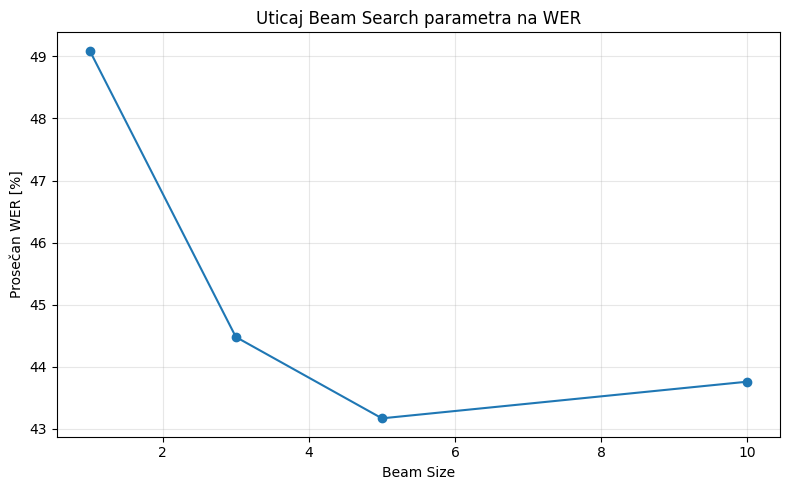

In [13]:
# ============================================================
# GRAFIK — BEAM SIZE VS WER
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    tabela_beam_final["Beam Size"],
    tabela_beam_final["Prosečan WER [%]"],
    marker="o"
)

plt.xlabel("Beam Size")
plt.ylabel("Prosečan WER [%]")
plt.title("Uticaj Beam Search parametra na WER")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Komentar WER rezultata

Prosečan WER opada sa **49,09%** za `beam_size = 1` na **44,48%** za `beam_size = 3`, a zatim na minimum od **43,17%** za `beam_size = 5`.

Kod `beam_size = 10` prosečan WER blago raste na **43,76%**. To pokazuje da povećavanje broja kandidata tokom dekodiranja ne dovodi nužno do monotonog poboljšanja WER-a.

Medijana WER-a se sa **51,85%** pri `beam_size = 1` smanjuje na **48,15%** pri `beam_size = 3`, nakon čega ostaje na istoj vrednosti za beam 5 i 10. Ovo dodatno ukazuje da najveće povećanje beam vrednosti ne donosi jednako poboljšanje na svim snimcima.


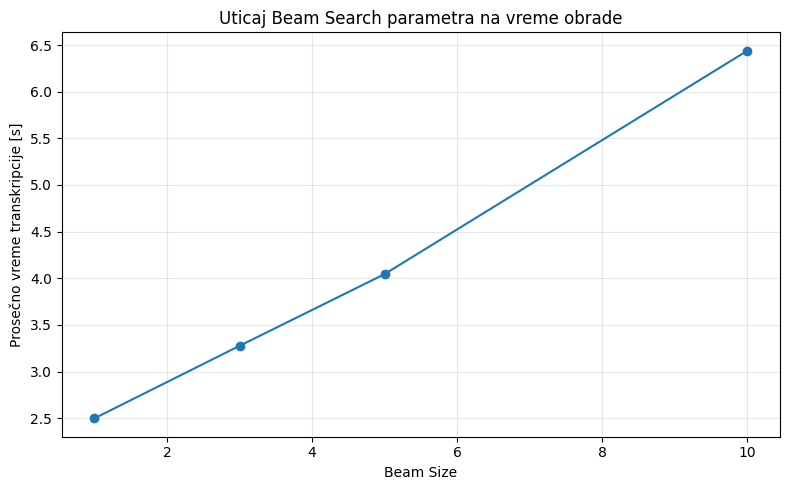

In [14]:
# ============================================================
# GRAFIK — BEAM SIZE VS VREME TRANskrIPCIJE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    tabela_beam_final["Beam Size"],
    tabela_beam_final["Prosečno vreme [s]"],
    marker="o"
)

plt.xlabel("Beam Size")
plt.ylabel("Prosečno vreme transkripcije [s]")
plt.title("Uticaj Beam Search parametra na vreme obrade")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Komentar vremena izvršavanja i RTF-a

Za razliku od WER-a, vreme izvršavanja pokazuje veoma jasan rast sa povećanjem `beam_size`.

Prosečno vreme raste sa **2,499 s** za beam 1, preko **3,276 s** za beam 3 i **4,045 s** za beam 5, do **6,439 s** za beam 10. Istovremeno prosečan RTF raste sa **0,1076** na **0,1218**, **0,1425** i konačno **0,1988**.

Iako su sve prosečne RTF vrednosti znatno manje od 1 i obrada je i dalje brža od realnog vremena, povećavanje `beam_size` jasno povećava računarski trošak dekodiranja.

Ovaj efekat je posebno izražen kod dužih snimaka, jer se dodatna pretraga kandidata primenjuje tokom većeg broja koraka dekodiranja.


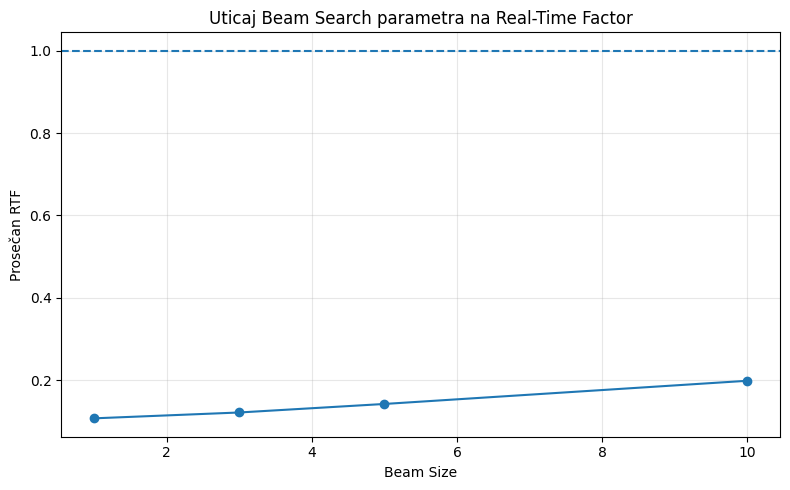

In [15]:
# ============================================================
# GRAFIK — BEAM SIZE VS RTF
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    tabela_beam_final["Beam Size"],
    tabela_beam_final["Prosečan RTF"],
    marker="o"
)

plt.axhline(
    1.0,
    linestyle="--"
)

plt.xlabel("Beam Size")
plt.ylabel("Prosečan RTF")
plt.title("Uticaj Beam Search parametra na Real-Time Factor")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# AUTOMATSKA PROCENA NAJBOLJEG REZULTATA
# ============================================================

najmanji_wer_red = tabela_beam_final.loc[
    tabela_beam_final["Prosečan WER [%]"].idxmin()
]

najbrzi_red = tabela_beam_final.loc[
    tabela_beam_final["Prosečno vreme [s]"].idxmin()
]


print("=" * 90)
print("ZAVRŠNI REZIME — BEAM SEARCH")
print("=" * 90)

print(
    f"Najniži prosečan WER: beam_size = "
    f"{int(najmanji_wer_red['Beam Size'])}, "
    f"WER = {najmanji_wer_red['Prosečan WER [%]']:.2f}%"
)

print(
    f"Najbrža konfiguracija: beam_size = "
    f"{int(najbrzi_red['Beam Size'])}, "
    f"prosečno vreme = {najbrzi_red['Prosečno vreme [s]']:.2f} s"
)

print("\nKompletna tabela:")
display(tabela_beam_final)

ZAVRŠNI REZIME — BEAM SEARCH
Najniži prosečan WER: beam_size = 5, WER = 43.17%
Najbrža konfiguracija: beam_size = 1, prosečno vreme = 2.50 s

Kompletna tabela:


,Beam Size,Broj snimaka,Prosečno vreme [s],Ukupno vreme [s],Prosečan RTF,Prosečan WER [%],Medijana WER [%],Corpus WER [%]
0,1,15,2.499,37.482,0.1076,49.09,51.85,49.03
1,3,15,3.276,49.145,0.1218,44.48,48.15,43.48
2,5,15,4.045,60.674,0.1425,43.17,48.15,43.00
3,10,15,6.439,96.586,0.1988,43.76,48.15,42.39


## Analiza corpus WER-a

Corpus WER pokazuje sličan opšti trend, ali otkriva i razliku u odnosu na prosečan WER po snimku.

Corpus WER iznosi **49,03%** za `beam_size = 1`, **43,48%** za beam 3, **43,00%** za beam 5 i **42,39%** za beam 10.

Dakle, dok je **najniži prosečan WER po snimku** ostvaren sa `beam_size = 5`, **najniži corpus WER** ostvaren je sa `beam_size = 10`.

Razlika nastaje zato što prosečan WER svim snimcima daje jednaku težinu, dok corpus WER dužim referentnim tekstovima daje proporcionalno veći uticaj. Zbog toga se ne može tvrditi da jedna beam vrednost daje najmanju grešku prema svakoj korišćenoj WER agregaciji.


In [17]:
# ============================================================
# ČUVANJE REZULTATA
# ============================================================

df_detaljno.to_csv(
    REZULTATI_DIR / "04_beam_svi_rezultati.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_beam_final.to_csv(
    REZULTATI_DIR / "04_beam_rezime.csv",
    index=False,
    encoding="utf-8-sig"
)

rezime_duzine.to_csv(
    REZULTATI_DIR / "04_beam_po_duzini.csv",
    index=False,
    encoding="utf-8-sig"
)

rezime_govornici.to_csv(
    REZULTATI_DIR / "04_beam_po_govorniku.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_promena.to_csv(
    REZULTATI_DIR / "04_beam_promena_u_odnosu_na_beam1.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Rezultati su sačuvani u:")
print(REZULTATI_DIR)

Rezultati su sačuvani u:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\04_uticaj_beam_searcha


## Zaključak eksperimenta

Eksperiment pokazuje da `beam_size` direktno utiče na odnos između tačnosti i brzine Faster-Whisper transkripcije.

Povećanjem `beam_size` sa 1 na 5 prosečan WER smanjen je sa **49,09% na 43,17%**, odnosno za **5,92 procentna poena**, dok je prosečno vreme obrade poraslo sa **2,499 s na 4,045 s**, što predstavlja približno **1,62 puta duže izvršavanje**.

Dalje povećanje na `beam_size = 10` povećalo je prosečno vreme na **6,439 s**, odnosno približno **2,58 puta** u odnosu na beam 1, dok prosečan WER nije dodatno poboljšan i iznosi **43,76%**. Sa druge strane, corpus WER je nastavio blago da opada i dostigao najmanju vrednost od **42,39%** pri beam 10.

Rezultati zato pokazuju da povećavanje beam vrednosti može poboljšati tačnost, ali uz sve veći vremenski trošak i bez garantovanog proporcionalnog poboljšanja. Na ovom skupu `beam_size = 5` ostvaruje najniži prosečan WER, dok `beam_size = 10` ostvaruje najniži corpus WER uz znatno veće vreme izvršavanja.

Izbor beam vrednosti zato zavisi od prioriteta konkretne primene: manji beam pogoduje brzini, dok veće vrednosti mogu dati veću tačnost uz dodatni računarski trošak.
